# Essay for Assignment, Course MZ340V17, 2025

This is an essay covering the [assignment](https://martinfleischmann.net/sds/micro/course_information/assignment.html) for [Course MZ340V17, 2025](https://martinfleischmann.net/sds/micro/).

## Parts Covered

This covers Part one and Part two, choosing option two of Part two.

In [1]:
import geopandas as gpd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import esda
import matplotlib.pyplot as plt
from libpysal import graph
import tobler
import contextily
import pointpats
import numpy as np
from scipy import interpolate
from sklearn import cluster

# Part one

## Derive Census Areas

The definition of census areas, `BarcelonaCiutat_SeccionsCensals.csv`, comes from ["Detail of administrative units of the city of Barcelona : districts, neighbourhoods, Interés area, basic statistical areas (AEB) and census areas"](https://opendata-ajuntament.barcelona.cat/data/en/dataset/20170706-districtes-barris/resource/e16856a7-b3c0-4c32-a468-cc190cbbf7a9).

From looking through a sample of the datasets on the [Open Data BCN ](https://opendata-ajuntament.barcelona.cat/data/en/dataset) website, many of them have a "Seccio_Censal" column which is a combination of the District Code and the Census Code ("Seccio_Censal"), and so we use this definition here.

In [2]:
from shapely import from_wkt

def combine_districts_and_census_areas(df, district_column='codi_districte', census_column='codi_seccio_censal'):
    """Combines districts and census areas into a single column, `Seccio_Censal`."""
    df["Seccio_Censal"] = (
        (df[district_column] * 1000 ) + df[census_column]
    )

GLOBAL_CRS = "EPSG:4326"
BARCELONA_CRS = "EPSG:25831"

def barcelona_census_areas(url="BarcelonaCiutat_SeccionsCensals.csv"):
    """This loads the census areas as defined in a CSV file, and returns a 
    GDF with a single `Seccio_Censal` column and associated geometry.

    The geometry is in a local Barcelona Projected CRS to make later area-related operations more correct.
    
    The `Seccio_Censal` column is the combination of the `codi_districte` and `codi_seccio_censal`.
    """
    df = pd.read_csv(url)
    combine_districts_and_census_areas(df)
    
    df["geometry"] = df["geometria_wgs84"].apply(from_wkt)
    df = df[["Seccio_Censal","geometry"]]
    
    assert df["Seccio_Censal"].is_unique
    df.set_index("Seccio_Censal")
    
    geographic_gdf = gpd.GeoDataFrame(df,geometry="geometry",crs=GLOBAL_CRS)
    projected_gdf = geographic_gdf.to_crs(BARCELONA_CRS)
    
    return projected_gdf

In [3]:
census_areas_gdf = barcelona_census_areas()

In [4]:
census_areas_gdf.head(2)

,Seccio_Censal,geometry
0,1001,"POLYGON ((431076.902 4581077.309, 431058.164 4..."
1,1002,"POLYGON ((431023.545 4581164.326, 430990.55 45..."


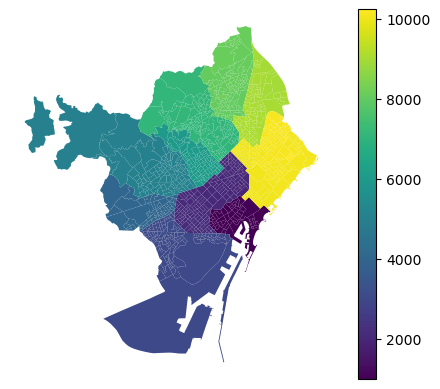

In [5]:
ax = census_areas_gdf.plot("Seccio_Censal", legend=True)
ax.set_axis_off()

## Choosing Socio-economic variables

There are many variables we could choose from. For simplicity we choose population and income to give both social and economic coverage:
* population is from ["Population of Barcelona according to the Municipal Register of Inhabitants on January 1 of each year"](https://opendata-ajuntament.barcelona.cat/data/en/dataset/pad_mdbas/resource/eb82adf2-a7b0-40e6-9624-b4b9eff23018)
* income is from ["Average gross taxable income per person (€) in the city of Barcelona based on Atlas de distribución de la renta de los hogares of Instituto Nacional de Estadística (INE)"](https://opendata-ajuntament.barcelona.cat/data/en/dataset/atles-renda-bruta-per-persona/resource/e6cabd96-68d6-451b-bc9f-c2a381d733e6)


In [6]:
def load_population_dataset(year):
    """Load population of Barcelona for a particular year; index is by `Seccio_Censal`.
    
    It is assumed data has been downloaded locally in a CSV prefixed by year.
    """
    df = pd.read_csv(f"{year}_pad_mdbas.csv")
    df["population"] = df["Valor"].astype(float)
    df = df[["population","Seccio_Censal"]]
    df.set_index("Seccio_Censal")
    return df

def load_income_dataset(year):
    """Load income of Barcelona for a particular year; index is by `Seccio_Censal`.

    It is assumed data has been downloaded locally in a CSV prefixed by year.
    """
    df = pd.read_csv(f"{year}_atles_renda_bruta_persona.csv")
    df["income"] = df["Import_Renda_Bruta_€"].astype(float)
    combine_districts_and_census_areas(df, district_column='Codi_Districte',census_column='Seccio_Censal')
    
    df = df[["income","Seccio_Censal"]]
    df.set_index("Seccio_Censal")
    return df

We choose a shared year that is the latest year both of the datasets are available.

In [7]:
shared_year=2023

population_df = load_population_dataset(shared_year)
population_df.head(2)

,population,Seccio_Censal
0,1246.0,1001
1,1238.0,1002


In [8]:
income_df = load_income_dataset(shared_year)
income_df.head(2)

,income,Seccio_Censal
0,17113.0,1001
1,13081.0,1002


## Merge with Census Areas

We can now merge these into the census areas to produce one GeoDataFrame for our analysis

In [9]:
def merge_in_dataframes(gdf, dfs):
    """Merge multiple DataFrames into a GeoDataFrame, based on index."""
    merged_gdf = gdf
    for df in dfs:
        merged_gdf = merged_gdf.merge(df)
    return merged_gdf

In [10]:
barcelona_gdf = merge_in_dataframes(census_areas_gdf, dfs=[population_df,income_df])
barcelona_gdf.head(2)

,Seccio_Censal,geometry,population,income
0,1001,"POLYGON ((431076.902 4581077.309, 431058.164 4...",1246.0,17113.0
1,1002,"POLYGON ((431023.545 4581164.326, 430990.55 45...",1238.0,13081.0


## Analysis

If we examine the chloropleths of each variable by eye we see a couple of things:
* for population, there appear to be a small number of areas with a lot of people, but apart from that there aren't many clear patterns
* for income, we see a few hotspots, particularly on the left-hand side, in an approximate "V" shape

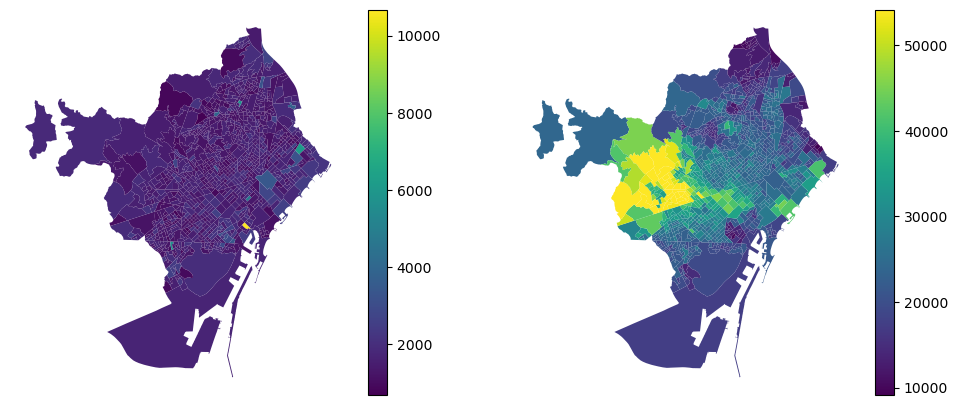

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
barcelona_gdf.plot("population", ax=axs[0], legend=True)
barcelona_gdf.plot("income", ax=axs[1], legend=True)
for ax in axs:
    ax.set_axis_off()
plt.show()

## Moran's I

To get a more rigorous idea of structure, we will first apply Moran I's at Global level. For each area, this takes a value of a variable in an area and compares it against the spatially-lagged value for the neighhourhood (contiguity) of that area.

In our definition here, because we are using the row-standardized contiguity for a census area, we end up with the spatially-lagged average population or income of each census area.


In [12]:
def std_dev(df, column, std_column=None):
    std_df = df.copy(deep=True)
    if std_column is None:
        std_column = f"{column}_std"
    
    std_df[std_column] = (
        std_df[column] - std_df[column].mean()
    ) / std_df[column].std()

    return std_df
    
def build_averaging_queen_contiguity(gdf):
    """build a Queen contiguity that is transformed to support averaging across nieghbours"""
    contiguity = graph.Graph.build_contiguity(gdf, rook=False)
    contiguity_r = contiguity.transform("r")

    return contiguity_r

def moran_global(gdf, column, crit_value=0.05):
    """Does a Global Spatial analysis using Moran's I for this dataset, and returns a plot 
    illustrating what is happening internally.
    """
 
    contiguity_r = build_averaging_queen_contiguity(gdf)
    
    # get ESDA to do the actual analysis
    moran = esda.Moran(gdf[column], contiguity_r)
    print(f"I: {moran.I}, P_sim: {moran.p_sim}, <{crit_value}?: {moran.p_sim < crit_value}")

    # redo the analysis as a visualisation
    std_column = f"{column}_std"
    lag_column = f"{column}_std_lag"
    std_gdf = std_dev(gdf, column, std_column=std_column)
    std_gdf[lag_column] = contiguity_r.lag(std_gdf[std_column])

    f, ax = plt.subplots(1, figsize=(6, 6))
    sns.regplot(
        x=std_column,
        y=lag_column,
        data=std_gdf,
        marker=".",
        scatter_kws={"alpha": 0.2},
        line_kws=dict(color="lightcoral")
    )
    ax.set_aspect('equal')
    plt.axvline(0, c="black", alpha=0.5)
    plt.axhline(0, c="black", alpha=0.5)

I: 0.09308043377892011, P_sim: 0.001, <0.05?: True


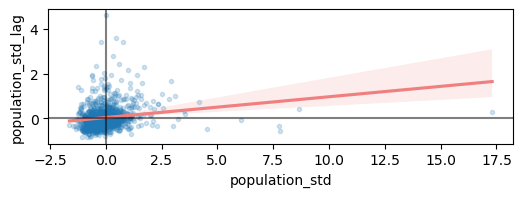

In [13]:
moran_global(barcelona_gdf, "population")

I: 0.8676035793980652, P_sim: 0.001, <0.05?: True


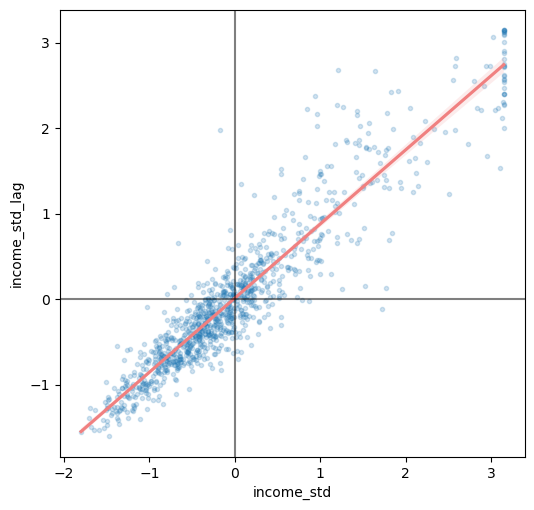

In [14]:
moran_global(barcelona_gdf, "income")

For both of these, because `P_sim` is less than 0.05 (5%), we can discount the null hypothesis that this correlation is random i.e. this is a real effect.

The value of Moran's I is greater for income than for population, which is consistent with our previous intuition: income is more spatially-correlated than population.

Note that I is particularly low for income, possibly caused by the large outlier, and the graph overall looks quite skewed. We shall aim to address some of this later with the grid.

## LISA (using Moran Local)

So, we have confidence that there are clusters, but we are also interested in what this looks on the actual map. For this we will use a LISA (Local Indicator of Spatial autocorrelation): Moran Local.

In [15]:
def moran_local_clusters(gdf, column, crit_value):
    """Does a Local Spatial analysis using Moran Local for this dataset, and returns the clusters."""

    contiguity_r = build_averaging_queen_contiguity(gdf)
    
    lisa_gdf = gdf.copy(deep=True)
    lisa = esda.Moran_Local(lisa_gdf[column], contiguity_r)

    lisa_gdf['cluster'] = lisa.get_cluster_labels(crit_value=crit_value)
    return lisa, lisa_gdf

In [16]:
crit_value=0.05
barcelona_population_lisa, barcelona_population_clusters_gdf = moran_local_clusters(
    barcelona_gdf, "population", crit_value)
barcelona_income_lisa, barcelona_income_clusters_gdf = moran_local_clusters(
    barcelona_gdf, "income", crit_value)

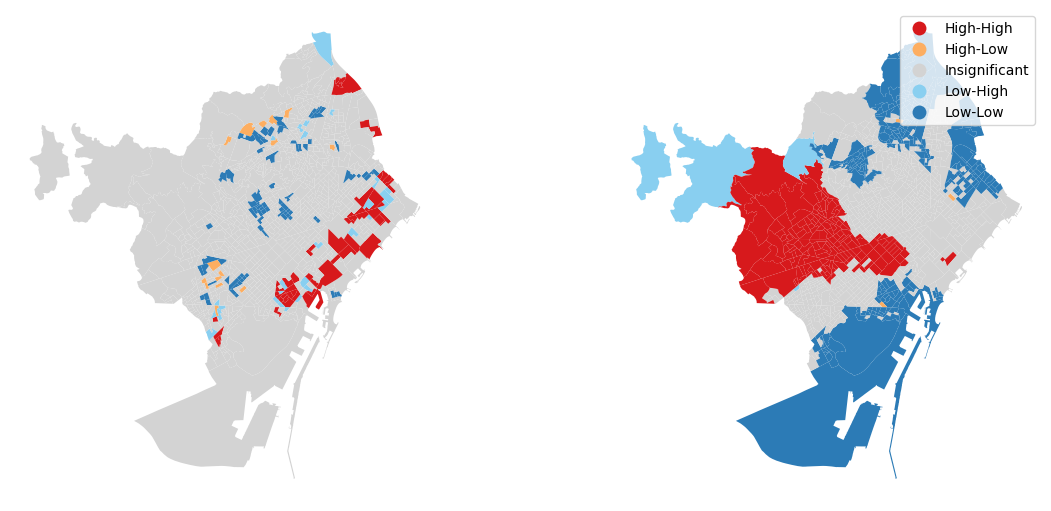

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
barcelona_population_lisa.plot(
    barcelona_population_clusters_gdf,
    crit_value=crit_value,
    ax=axs[0],
    legend=False
)
barcelona_income_lisa.plot(
    barcelona_income_clusters_gdf,
    crit_value=crit_value,
    ax=axs[1],
    legend=True
)
for ax in axs:
    ax.set_axis_off()
plt.show()

From this we can see that:
* for population, the largest clusters are of high-high population areas, near the center of barcelona and on the coastline, with the other cluster types less present
* for income, there is a mix of high-high (including the V-shape we saw previously), with low-low areas on north and south. There are also a couple of areas on the outskirts at north-west that are low-high

## Controlling for size

We saw in the last section that we were getting some areas that were large and appearing in clusters. This can be misleading as the larger areas have a greater chance of being contiguous to other areas, which can skew the results. We also some weird results for Moran's I on income.

To gaurd against this we will repeat our analysis using a grid of areas where each area has approximately the same size. We will use [H3](https://h3geo.org) here which can still vary in size over different areas of whole earth (so would be invalid for comparison across cities, for example), but does not have meaningful variance over barcelona itself.

In [18]:
def build_safe_grid(gdf, resolution):
    """Builds a safe H3 grid, where safe means it has no isolates.

    Some later operations don't work if we have isolates (areas with no nieghbours), so we exclude them here.
    """
    initial_grid_gdf = tobler.util.h3fy(gdf.to_crs(GLOBAL_CRS), resolution=resolution)
    
    # build a Queen contiguity and use it solely to exclude the isolates from the grid
    contiguity = graph.Graph.build_contiguity(initial_grid_gdf, rook=False)
    isolates = contiguity.isolates
    filtered_grid_gdf = initial_grid_gdf[~initial_grid_gdf.index.isin(isolates)]
    
    return filtered_grid_gdf.to_crs(BARCELONA_CRS)

In [19]:
barcelona_grid_gdf = build_safe_grid(barcelona_gdf, resolution=9)
barcelona_grid_gdf.head(2)

,geometry
hex_id,
893944600c7ffff,"POLYGON ((427196.023 4583924.062, 427351.374 4..."
8939446352bffff,"POLYGON ((423400.197 4586604.058, 423374.683 4..."


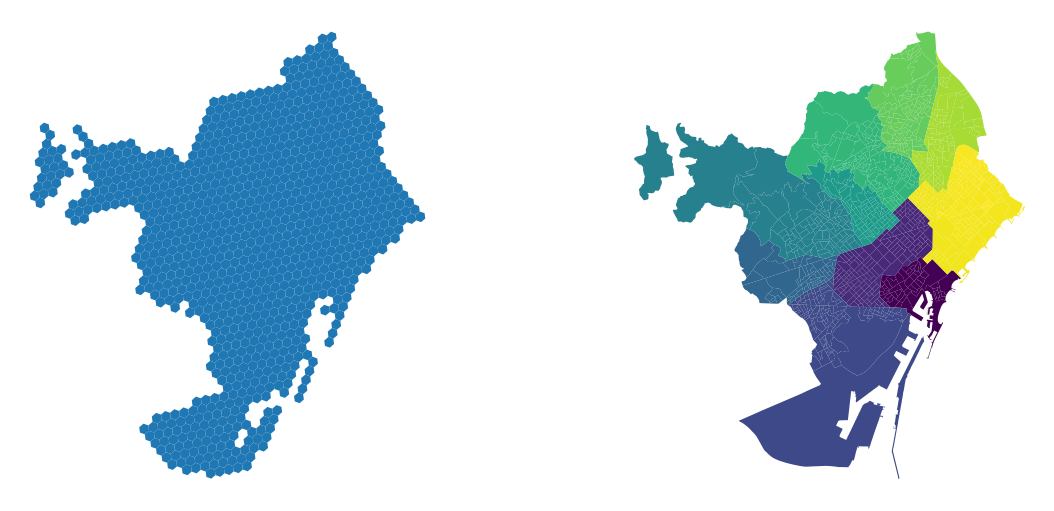

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
barcelona_grid_gdf.plot(ax=axs[0])
census_areas_gdf.plot("Seccio_Censal", ax=axs[1])
for ax in axs:
    ax.set_axis_off()
plt.show()

## Interpolation

We need to interpolate our variables from the original census areas onto the grid, based on the area of overlap. We choose:
* population as an extensive variable as it was the sum over the census area, and so needs to be divided across grid areas, and
* income as an intensive variable, as it's actually average income, and so needs to be assumed the same across all overlapping areas. however, grid areas will stil be apportioned different incomes based on what area of overlap they have.

In [21]:
barcelona_interpolated_gdf = tobler.area_weighted.area_interpolate(
    source_df=barcelona_gdf, 
    target_df=barcelona_grid_gdf,
    extensive_variables=["population"],
    intensive_variables=["income"]
)

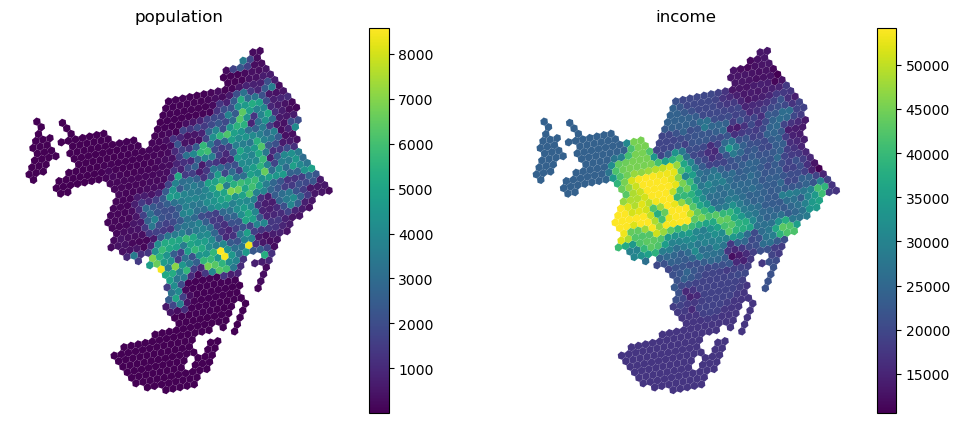

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
barcelona_interpolated_gdf.plot("population", ax=axs[0], legend=True)
barcelona_interpolated_gdf.plot("income", ax=axs[1], legend=True)
axs[0].set_title(f"population")
axs[1].set_title(f"income")
for ax in axs:
    ax.set_axis_off()
plt.show()

### Moran's I

I: 0.8063764552637569, P_sim: 0.001, <0.05?: True


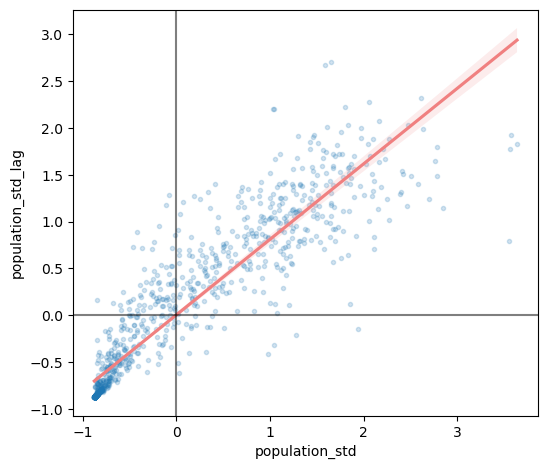

In [23]:
moran_global(barcelona_interpolated_gdf, "population")

I: 0.9403212329834736, P_sim: 0.001, <0.05?: True


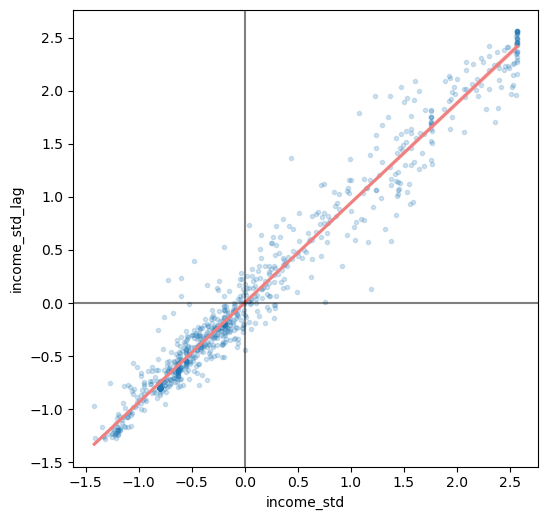

In [24]:
moran_global(barcelona_interpolated_gdf, "income")

Again, we see both are significant, and Moran's I is greater for population than income. However, we also see the graph for income is far cleaner, with less outlier, and a far higher valuen of Moran's I.

### LISA

In [25]:
crit_value=0.05
barcelona_interpolated_population_lisa, barcelona_interpolated_population_clusters_gdf = moran_local_clusters(
    barcelona_interpolated_gdf, "population", crit_value)
barcelona_interpolated_income_lisa, barcelona_interpolated_income_clusters_gdf = moran_local_clusters(
    barcelona_interpolated_gdf, "income", crit_value)

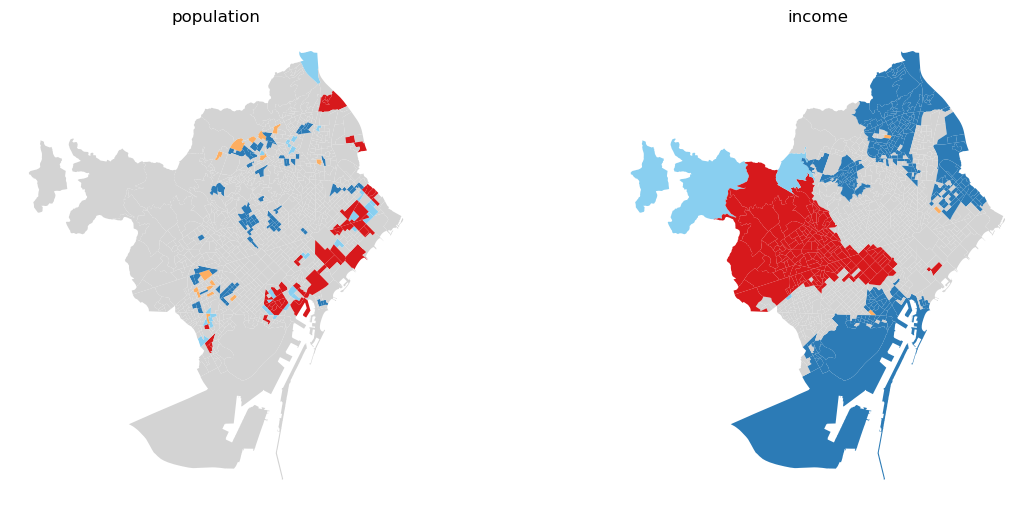

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
axs = axs.flatten()
axs[0].set_title(f"population")
axs[1].set_title(f"income")
barcelona_population_lisa.plot(
    barcelona_population_clusters_gdf,
    crit_value=crit_value,
    ax=axs[0],
    legend=False
)
barcelona_income_lisa.plot(
    barcelona_income_clusters_gdf,
    crit_value=crit_value,
    ax=axs[1],
    legend=False
)
for ax in axs:
    ax.set_axis_off()
plt.show()

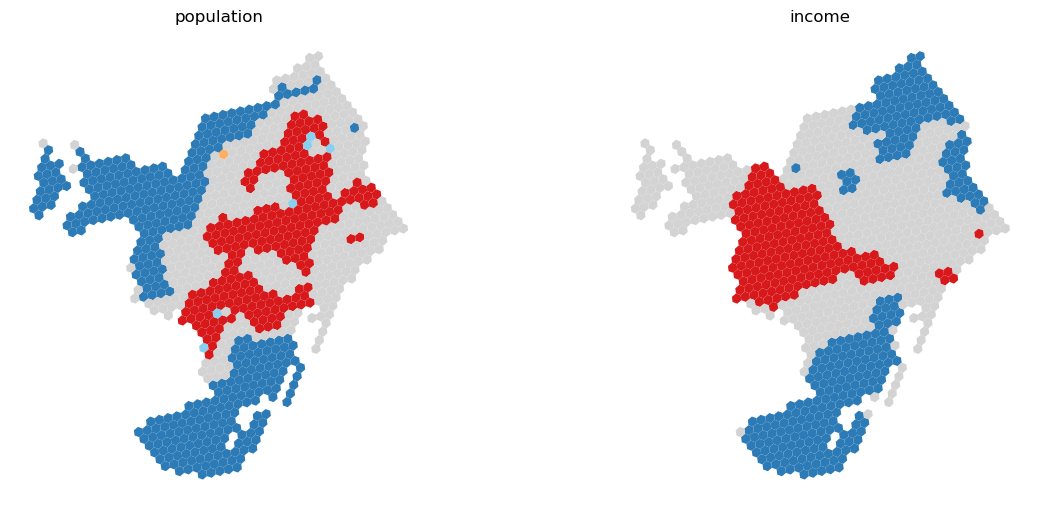

In [27]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
axs = axs.flatten()
axs[0].set_title(f"population")
axs[1].set_title(f"income")
barcelona_interpolated_population_lisa.plot(
    barcelona_interpolated_population_clusters_gdf,
    crit_value=crit_value,
    ax=axs[0],
    legend=False
)
barcelona_interpolated_income_lisa.plot(
    barcelona_interpolated_income_clusters_gdf,
    crit_value=crit_value,
    ax=axs[1],
    legend=False
)
for ax in axs:
    ax.set_axis_off()
plt.show()

Comparing back against the original LISA results, we see that income is roughly the same as before, but with the low-high area at north-west gone.

For population, it's quite different, as the global Moran I plot also was. Given the original skewed distribution, and the knowledge that operations such as mean are easily skewed by outlier values, we decide to conclude this grid-based summary of clusters is more accurate.

#  Part 2: Assess the distribution of Airbnbs in Barcelona

In [28]:
def airbnb_listings(city_path, quarter_end_dates):
    """load listings for a city_path for a series of dates (representing quarter ends) and combines into one DataFrame.

    Adds a new `quarter_end_date` column so that data for each quarter can still be pulled out later if needed.
    """
    listings_url_base = f"https://data.insideairbnb.com/{city_path}"
    dfs = []
    for quarter_end_date in quarter_end_dates:
        listings_url = f"{listings_url_base}/{quarter_end_date}/data/listings.csv.gz"
        df = pd.read_csv(listings_url, compression='gzip')
        df['quarter_end_date'] = quarter_end_date
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

## Prepare Airbnb data

If we were trying to be maximally consistent with the year used for Part 1 analysis, then we'd load data for 2023. However, 2023 was still mid-COVID, when we'd expect data for Airbnb to be not representative of normal behaviour. Using 2023 for population and income was fine, as long as we can assume these do not change rapidly.

So we load data for listings for quarters going from Q4 2024 to Q3 2025. We load a full set of four quarters so that we don't get skewed by seasonal effects.

In [29]:
airbnb_df = airbnb_listings("spain/catalonia/barcelona", ["2024-12-12","2025-03-05","2025-06-12","2025-09-14"])
airbnb_df.head(2)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,quarter_end_date,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d
0,18674,https://www.airbnb.com/rooms/18674,20241212051318,2024-12-12,city scrape,Huge flat for 8 people close to Sagrada Familia,110m2 apartment to rent in Barcelona. Located ...,Apartment in Barcelona located in the heart of...,https://a0.muscache.com/pictures/13031453/413c...,71615,...,29,29,0,0,0.32,2024-12-12,NaN,NaN,NaN,NaN
1,23197,https://www.airbnb.com/rooms/23197,20241212051318,2024-12-12,city scrape,"Forum CCIB DeLuxe, Spacious, Large Balcony, relax",Beautiful and Spacious Apartment with Large Te...,"Strategically located in the Parc del Fòrum, a...",https://a0.muscache.com/pictures/miso/Hosting-...,90417,...,1,1,0,0,0.48,2024-12-12,NaN,NaN,NaN,NaN


We're going to be looking at prices and listing types. It's going to be fine seeing the same listings repeatedly for prices, as we want to be exposed to prices over time. However, for listings we want to include all listings seen throughout a year but remove duplicates.

In [30]:
def create_gdf_from_latlon(df, crs):
    """creates a new GDF from a Dataframe containing `latitude` and `longitude` columns, but then projects it to a CRS"""
    geometry = gpd.points_from_xy(df['longitude'], df['latitude'], crs="EPSG:4326")
    return gpd.GeoDataFrame(df, geometry=geometry).to_crs(crs)

In [31]:
airbnb_gdf = create_gdf_from_latlon(airbnb_df, crs=BARCELONA_CRS)
airbnb_gdf.head(2)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,quarter_end_date,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,geometry
0,18674,https://www.airbnb.com/rooms/18674,20241212051318,2024-12-12,city scrape,Huge flat for 8 people close to Sagrada Familia,110m2 apartment to rent in Barcelona. Located ...,Apartment in Barcelona located in the heart of...,https://a0.muscache.com/pictures/13031453/413c...,71615,...,29,0,0,0.32,2024-12-12,NaN,NaN,NaN,NaN,POINT (430844.039 4584109.916)
1,23197,https://www.airbnb.com/rooms/23197,20241212051318,2024-12-12,city scrape,"Forum CCIB DeLuxe, Spacious, Large Balcony, relax",Beautiful and Spacious Apartment with Large Te...,"Strategically located in the Parc del Fòrum, a...",https://a0.muscache.com/pictures/miso/Hosting-...,90417,...,1,0,0,0.48,2024-12-12,NaN,NaN,NaN,NaN,POINT (434790.298 4584836.252)


In [32]:
def types_only(gdf):
    """Takes a GDF and finds all columns whose name contains `type`, and filters out any rows with no values or empty string.

    It keeps any columns that related to identity.
    """
    types_gdf = gdf.copy(deep=True)
    
    # find columns related to `type`
    columns = types_gdf.columns
    type_cols = list(columns[columns.str.contains("type")])
    keep_cols = type_cols + ["id",types_gdf.geometry.name]
    types_gdf = types_gdf[keep_cols]

    # remove any rows with empty strings or missing values
    for col in type_cols:
        types_gdf[col] = (
            types_gdf[col].str.replace(r"^\s*$", "", regex=True).replace("", None)
        )
    types_gdf = types_gdf.dropna()

    # use geometry to drop any duplicate listings
    # note that using `id` in the original dataset is not enough; perhaps the same airbnb is registered multiple times?
    types_gdf["geom_id"] = types_gdf.geometry.apply(lambda geom: geom.wkt)
    types_gdf = types_gdf.drop_duplicates("geom_id")
    types_gdf = types_gdf.drop("geom_id", axis=1)
    
    return types_gdf

In [33]:
airbnb_types_gdf = types_only(airbnb_gdf)
airbnb_types_gdf.head()

,property_type,room_type,id,geometry
0,Entire rental unit,Entire home/apt,18674,POINT (430844.039 4584109.916)
1,Entire rental unit,Entire home/apt,23197,POINT (434790.298 4584836.252)
2,Entire rental unit,Entire home/apt,32711,POINT (430637.69 4584122.993)
3,Entire condo,Entire home/apt,34241,POINT (431030.822 4581339.081)
4,Entire rental unit,Entire home/apt,34981,POINT (431118.57 4581244.982)


## Density

> Q: Are the Airbnb listings distributed equally across the city?

No. We can see this if we use a plot of density at different bandwidths. We can see non-equal structure.

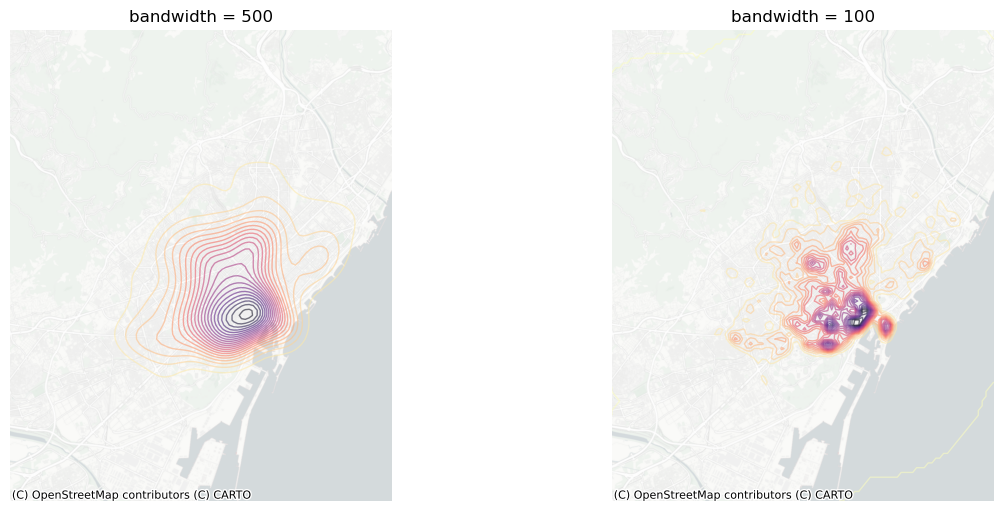

In [34]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
bandwidths = [500,100] # in metres as we're using a projected CRS
for ax, bandwidth in zip(axs, bandwidths):
    ax.set_title(f"bandwidth = {bandwidth}")
    pointpats.plot_density(
        airbnb_types_gdf,
        bandwidth=bandwidth,
        levels=25,
        alpha=0.55,
        cmap="magma_r",
        linewidths=1,
        ax=ax,
    )
    contextily.add_basemap(
        ax=ax,
        crs=airbnb_types_gdf.crs,
        source="CartoDB Positron No Labels",
    )
    ax.set_axis_off()

## Dependency on Listing and Price

> Q: Does it depend on the type of listing or its price?

This question is interpreted as meaning:
1. What is the density distribuition across grid areas from Part one?
2. What are spatial clusters of listing and price?
3. Do these clusters appear in same areas as the density hotspots?

### Density on Grid

In [35]:
def airbnb_counts_per_area(area_gdf, airbnb_gdf, area_key):
    # find the original area that contains the airbnb
    joined_gdf = gpd.sjoin(area_gdf, airbnb_gdf, how="left", predicate="contains")
    
    # rollup to create a count
    counts_per_area = (
        joined_gdf
        .groupby(area_key)
        .size()
        .rename("airbnb_count")
    )

    return area_gdf.join(counts_per_area, on=area_key)

In [36]:
airbnb_counts_grid_gdf = airbnb_counts_per_area(barcelona_grid_gdf, airbnb_types_gdf, area_key='hex_id')
airbnb_counts_grid_gdf.head(2)

,geometry,airbnb_count
hex_id,,
893944600c7ffff,"POLYGON ((427196.023 4583924.062, 427351.374 4...",5
8939446352bffff,"POLYGON ((423400.197 4586604.058, 423374.683 4...",1


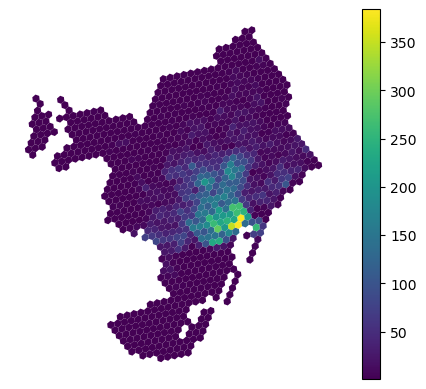

In [37]:
ax = airbnb_counts_grid_gdf.plot("airbnb_count", legend=True)
ax.set_axis_off()

Here we can see the hotspot in roughly the same place

### Listing Type

We can look at the distributions of `room_type` and `property_type` and see that they are both heavily skewed towards a small number of types.

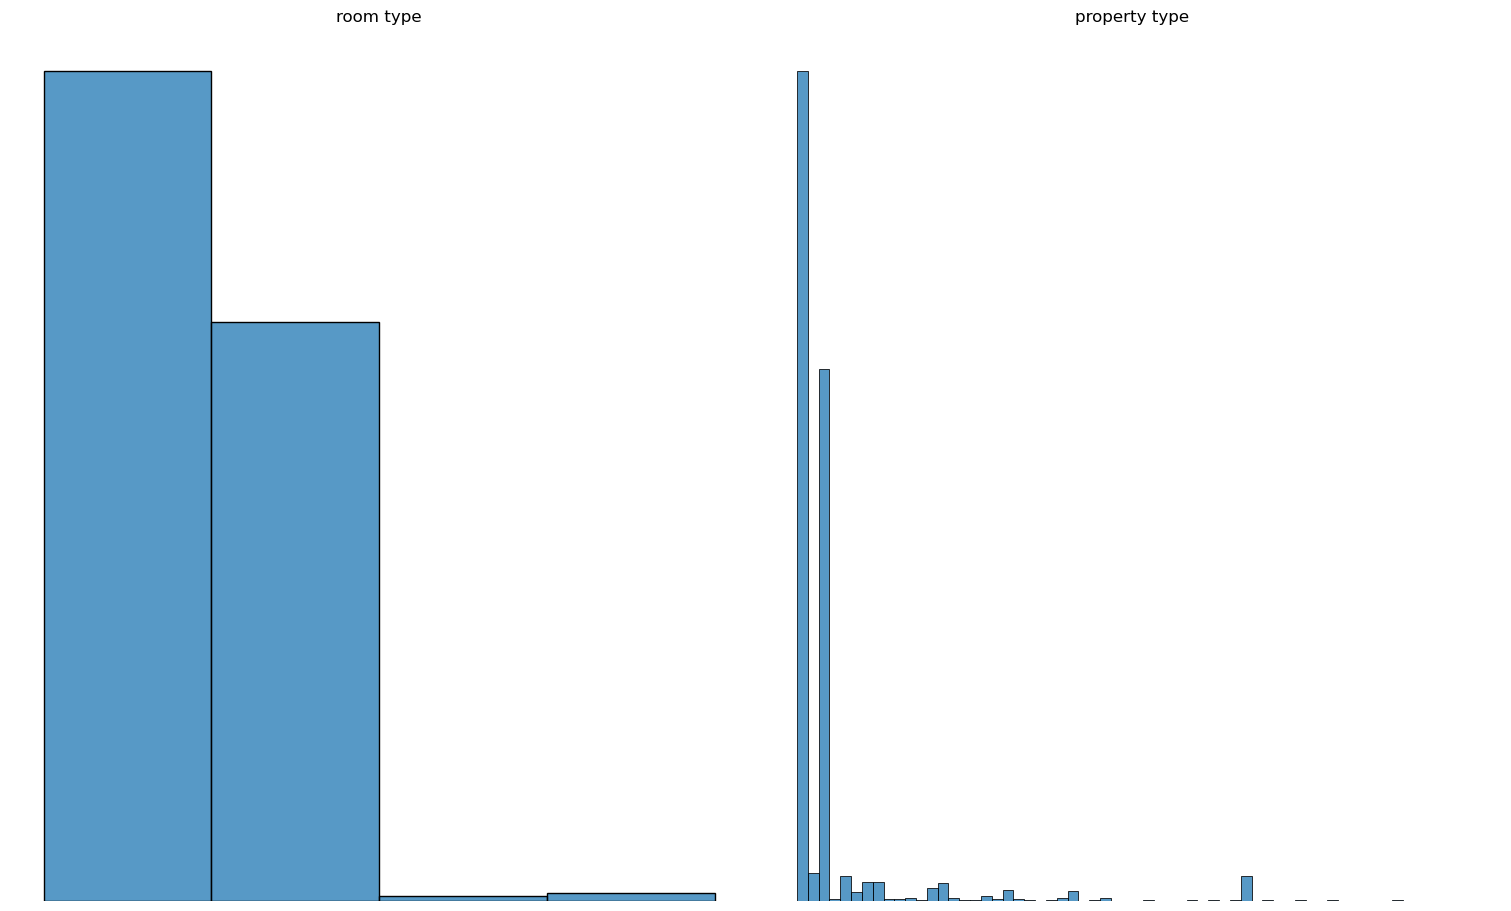

In [38]:
fig, axs = plt.subplots(1, 2, figsize=(15, 9), layout="constrained")
axs[0].set_title("room type")
axs[1].set_title("property type")
sns.histplot(airbnb_types_gdf["room_type"], ax=axs[0])
sns.histplot(airbnb_types_gdf["property_type"], ax=axs[1])
for ax in axs:
    ax.set_axis_off()
plt.show()

Dealing with categorical variables is difficult, so we can take advantage by treating `room_type` as a binary variable, which we can ultimately treat as a proportion i.e. we look at whether room_type is `Entire home/apt` or not and then look at clusters of these.

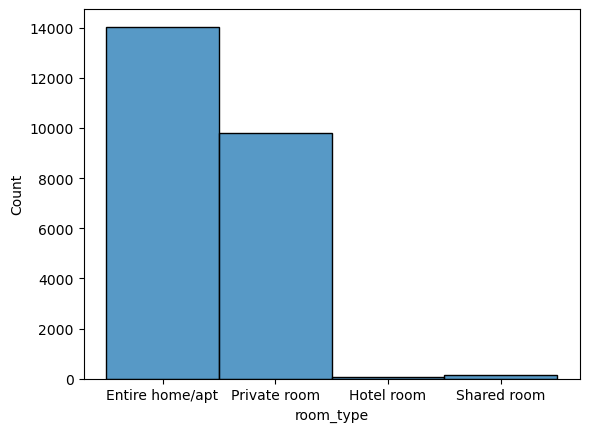

In [39]:
_ = sns.histplot(airbnb_types_gdf["room_type"])

In [40]:
def binarise_room_type(types_gdf, room_type):
    binarised_gdf = types_gdf.copy(deep=True)
    binarised = (binarised_gdf["room_type"] == room_type).astype(float)
    binarised_gdf["room_type_binarised"] = binarised
    return binarised_gdf

In [41]:
airbnb_entire_home_gdf = binarise_room_type(airbnb_types_gdf, room_type="Entire home/apt")
airbnb_entire_home_gdf.head()

,property_type,room_type,id,geometry,room_type_binarised
0,Entire rental unit,Entire home/apt,18674,POINT (430844.039 4584109.916),1.0
1,Entire rental unit,Entire home/apt,23197,POINT (434790.298 4584836.252),1.0
2,Entire rental unit,Entire home/apt,32711,POINT (430637.69 4584122.993),1.0
3,Entire condo,Entire home/apt,34241,POINT (431030.822 4581339.081),1.0
4,Entire rental unit,Entire home/apt,34981,POINT (431118.57 4581244.982),1.0


We can then build a `distance_band` which finds all airbnbs within `metre_threshold` and then 'average' the binary variable. This effectively is finding the proportion of listings which are "Entire home/apt" within this `metre_threshold` radius of each listing.

We're going to be later interpolating onto a hexagonal city grid, so we set the threshold based on the average radius of the hexes, treating a hex as a circle.

In [42]:
radius = np.sqrt(barcelona_grid_gdf.area / np.pi)
radius.mean()

np.float64(180.4633999425973)

In [43]:
meter_threshold = 180
airbnb_types_distance_contiguity = graph.Graph.build_distance_band(airbnb_entire_home_gdf, threshold=meter_threshold)
airbnb_types_distance_contiguity_r = airbnb_types_distance_contiguity.transform("r")

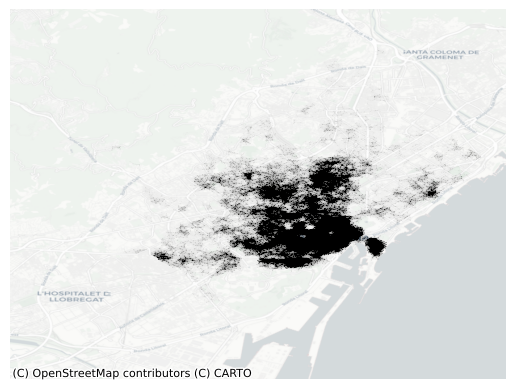

In [44]:
ax = airbnb_types_distance_contiguity_r.plot(airbnb_entire_home_gdf, nodes=False, edge_kws={"linewidth": .001})
contextily.add_basemap(ax=ax, crs=airbnb_entire_home_gdf.crs, source="CartoDB Positron")
ax.set_axis_off()

In [45]:
airbnb_types_contiguity_lag = airbnb_types_distance_contiguity_r.lag(airbnb_entire_home_gdf["room_type_binarised"])
airbnb_entire_home_gdf["room_type_binarised_lag"] = airbnb_types_contiguity_lag

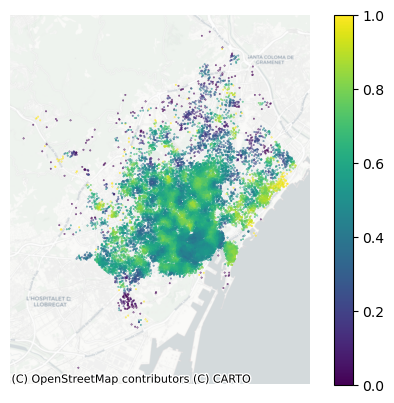

In [46]:
ax = airbnb_entire_home_gdf.plot("room_type_binarised_lag", markersize=0.1, legend=True)
contextily.add_basemap(ax=ax, crs=airbnb_entire_home_gdf.crs, source="CartoDB Positron")
ax.set_axis_off()

Then we can interpolate that back onto the main barcelona grid

In [47]:
room_type_binarised_lag_nearest = interpolate.griddata(
    points=airbnb_entire_home_gdf.get_coordinates(),
    values=airbnb_entire_home_gdf.room_type_binarised_lag,
    xi=barcelona_grid_gdf.centroid.get_coordinates(),
    method="nearest",
)

In [48]:
airbnb_entire_home_grid_gdf = barcelona_grid_gdf.copy(deep=True)
airbnb_entire_home_grid_gdf["room_type_binarised_lag_nearest"] = room_type_binarised_lag_nearest

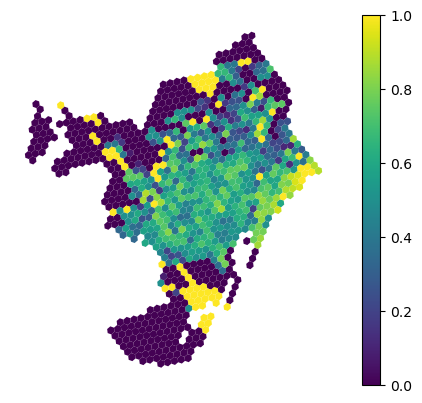

In [49]:
ax = airbnb_entire_home_grid_gdf.plot("room_type_binarised_lag_nearest", legend=True)
ax.set_axis_off()

I: 0.5705481047644564, P_sim: 0.001, <0.05?: True


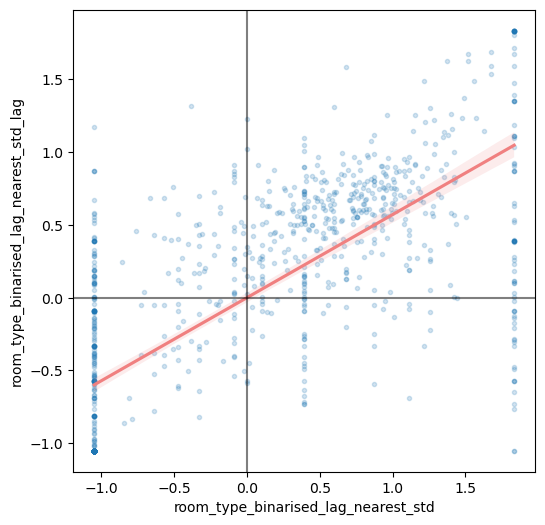

In [50]:
moran_global(airbnb_entire_home_grid_gdf, "room_type_binarised_lag_nearest")

In [51]:
airbnb_entire_home_grid_lisa, airbnb_entire_home_grid_clusters_gdf = moran_local_clusters(
    airbnb_entire_home_grid_gdf, "room_type_binarised_lag_nearest", crit_value)

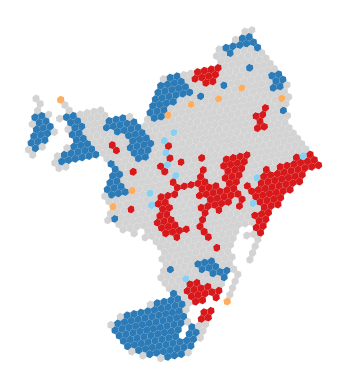

In [52]:
ax = airbnb_entire_home_grid_lisa.plot(
    airbnb_entire_home_grid_clusters_gdf,
    crit_value=crit_value,
    legend=False)
ax.set_axis_off()

This then gets us to a set of clusters, where high-high is interpreted as "entire home listings next to same listings" and low-low as "non-entire home listings next to same listings"

### Prices

We do something similar for prices, except we don't need to map it to a continuous variable.

In [53]:
def price_only(gdf):
    """Takes a GDF with a `price` column formatted as a $100.00 string and turns it into a float `price` column.
    The `price` and geometry columns are returned in a new GDF.
    """
    price_gdf = gdf.copy(deep=True)
    price_gdf["price"] = (
        gdf["price"]
          .str.replace(r"[\$,]", "", regex=True)
          .astype(float)
    )
    price_gdf = price_gdf[["price", gdf.geometry.name]]
    price_gdf = price_gdf.dropna()
    return price_gdf

In [54]:
airbnb_prices_gdf = price_only(airbnb_gdf)
airbnb_prices_gdf.head(2)

,price,geometry
0,119.0,POINT (430844.039 4584109.916)
1,219.0,POINT (434790.298 4584836.252)


In [55]:
def mean_price_per_listing(gdf):
    tmp_gdf = gdf.copy(deep=True)
    tmp_gdf['geom_id'] = tmp_gdf.geometry.apply(lambda geom: geom.wkt)
    dissolved_gdf = tmp_gdf.dissolve(by='geom_id', aggfunc={'price':'mean'})
    dissolved_gdf = dissolved_gdf.reset_index()
    return dissolved_gdf.drop('geom_id', axis=1)

Listing price will vary over time, so we take the average of each listing

In [56]:
airbnb_mean_prices_gdf = mean_price_per_listing(airbnb_prices_gdf)
airbnb_mean_prices_gdf.head(2)

,geometry,price
0,POINT (423588.44 4585939.863),36.0
1,POINT (423988.635 4586510.304),65.0


In [57]:
airbnb_mean_prices_contiguity = graph.Graph.build_distance_band(airbnb_mean_prices_gdf, threshold=meter_threshold)
airbnb_mean_prices_contiguity_r = airbnb_mean_prices_contiguity.transform("r")

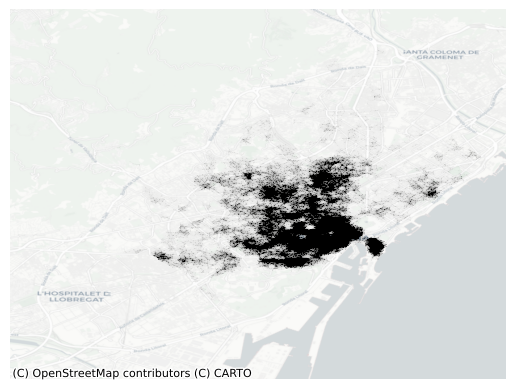

In [58]:
ax = airbnb_mean_prices_contiguity_r.plot(airbnb_mean_prices_gdf, nodes=False, edge_kws={"linewidth": .001})
contextily.add_basemap(ax=ax, crs=airbnb_mean_prices_gdf.crs, source="CartoDB Positron")
ax.set_axis_off()

In [59]:
airbnb_mean_prices_contiguity_lag = airbnb_mean_prices_contiguity_r.lag(airbnb_mean_prices_gdf["price"])
airbnb_mean_prices_gdf["price_lag"] = airbnb_mean_prices_contiguity_lag

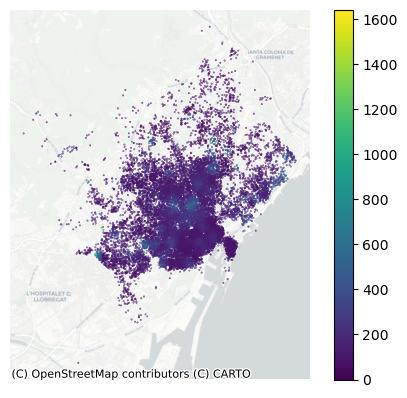

In [60]:
ax = airbnb_mean_prices_gdf.plot("price_lag", markersize=0.1, legend=True)
contextily.add_basemap(ax=ax, crs=airbnb_mean_prices_gdf.crs, source="CartoDB Positron")
ax.set_axis_off()

In [61]:
nearest_price = interpolate.griddata(
    points=airbnb_mean_prices_gdf.get_coordinates(),
    values=airbnb_mean_prices_gdf.price_lag,
    xi=barcelona_grid_gdf.centroid.get_coordinates(),
    method="nearest",
)

In [62]:
airbnb_mean_prices_grid_gdf = barcelona_grid_gdf.copy(deep=True)
airbnb_mean_prices_grid_gdf["nearest_price"] = nearest_price

I: 0.5073147169219658, P_sim: 0.001, <0.05?: True


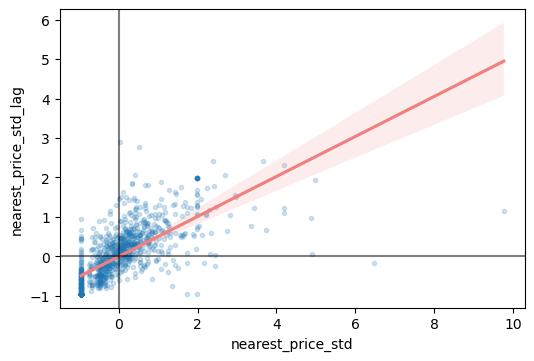

In [63]:
moran_global(airbnb_mean_prices_grid_gdf, "nearest_price")

In [64]:
airbnb_mean_prices_grid_lisa, airbnb_mean_prices_grid_clusters_gdf = moran_local_clusters(
    airbnb_mean_prices_grid_gdf, "nearest_price", crit_value)

### Bringing it together

Finally we can bring it together and show the airbnb density count alongside entire room and price clusters.

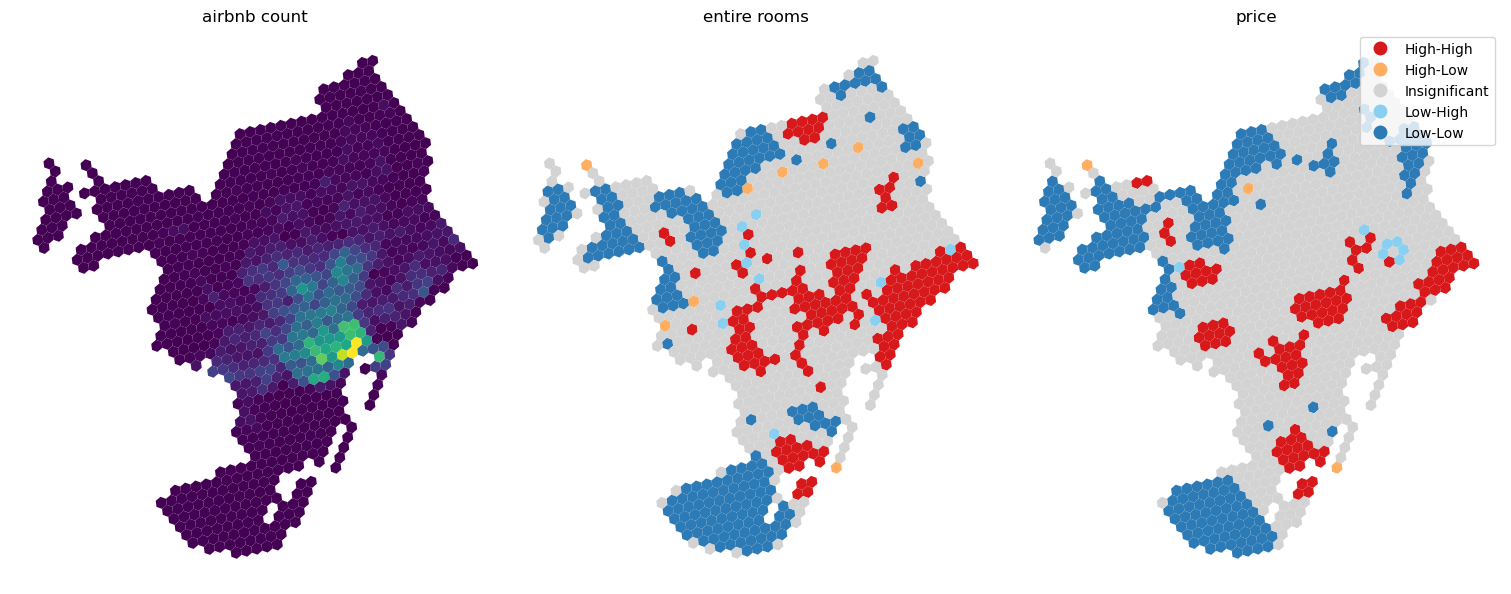

In [65]:
fig, axs = plt.subplots(1, 3, figsize=(15, 9), layout="constrained")
axs[0].set_title("airbnb count")
axs[1].set_title("entire rooms")
axs[2].set_title("price")
airbnb_counts_grid_gdf.plot("airbnb_count", ax=axs[0],legend=False)
airbnb_entire_home_grid_lisa.plot(
    airbnb_entire_home_grid_clusters_gdf,
    crit_value=crit_value,
    ax=axs[1],
    legend=False
)
airbnb_mean_prices_grid_lisa.plot(
    airbnb_mean_prices_grid_clusters_gdf,
    crit_value=crit_value,
    ax=axs[2],
    legend=True
)
for ax in axs:
    ax.set_axis_off()
plt.show()

Based on this, and using eyeballs alone to compare, there does not seem to be a correlation between hotspots in the airbnb count and listing type. So, re:

> Q: Does it depend on the type of listing or its price?

No, neither.

*Note that this is deliberately a simple interpretation for the sake of time. A more in-depth treatment would likely involve applying a regression, treating listing and pricing as predictors of the density variable. However, this will not be attempted here.*

### Regionalisation

> Can you create a regionalisation of Barcelona census areas based on the presence of Airbnbs?

We interpret this as:
1. Determine the number of Airbnb's per census area
2. Build an Agglomerative model between these areas based on count of airbnbs
3. Vary cluster number and visualise


#### Airbnb's per Census Area

We re-use `airbnb_counts_per_area` from above to get an airbnb count per census area.

In [66]:
airbnb_census_counts_gdf = airbnb_counts_per_area(barcelona_gdf, airbnb_types_gdf, area_key='Seccio_Censal')
airbnb_census_counts_gdf.head(2)

,Seccio_Censal,geometry,population,income,airbnb_count
0,1001,"POLYGON ((431076.902 4581077.309, 431058.164 4...",1246.0,17113.0,93
1,1002,"POLYGON ((431023.545 4581164.326, 430990.55 45...",1238.0,13081.0,85


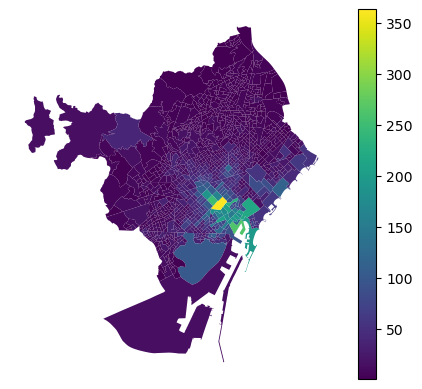

In [67]:
ax = airbnb_census_counts_gdf.plot("airbnb_count",legend=True)
ax.set_axis_off()

### Agglomerative Model visualised over multiple cluster sizes

In [68]:
def cluster_column(n):
    return f"agg_{n}"

def cluster_variants(gdf, columns, n_variants):
    cluster_gdf = gdf.copy(deep=True)
    queen_contiguity = graph.Graph.build_contiguity(cluster_gdf, rook=False)

    for n_clusters in n_variants:
        print(f"Agg on {columns} with {n_clusters} clusters...")
        agg = cluster.AgglomerativeClustering(n_clusters, connectivity=queen_contiguity.sparse)
        agg.fit(cluster_gdf[columns])
        agg_column = cluster_column(n_clusters)
        cluster_gdf[agg_column] = agg.labels_

    return cluster_gdf

In [69]:
n_variants=[2,3,4,5,6,7,8,9,10]
airbnb_counts_per_census_area_clusters_gdf = cluster_variants(
    airbnb_census_counts_gdf, 
    columns=["airbnb_count"], 
    n_variants=n_variants
)
airbnb_counts_per_census_area_clusters_gdf.head(2)

Agg on ['airbnb_count'] with 2 clusters...
Agg on ['airbnb_count'] with 3 clusters...
Agg on ['airbnb_count'] with 4 clusters...
Agg on ['airbnb_count'] with 5 clusters...
Agg on ['airbnb_count'] with 6 clusters...
Agg on ['airbnb_count'] with 7 clusters...
Agg on ['airbnb_count'] with 8 clusters...
Agg on ['airbnb_count'] with 9 clusters...
Agg on ['airbnb_count'] with 10 clusters...


,Seccio_Censal,geometry,population,income,airbnb_count,agg_2,agg_3,agg_4,agg_5,agg_6,agg_7,agg_8,agg_9,agg_10
0,1001,"POLYGON ((431076.902 4581077.309, 431058.164 4...",1246.0,17113.0,93,0,0,3,3,1,1,0,0,0
1,1002,"POLYGON ((431023.545 4581164.326, 430990.55 45...",1238.0,13081.0,85,0,0,3,3,1,1,0,0,0


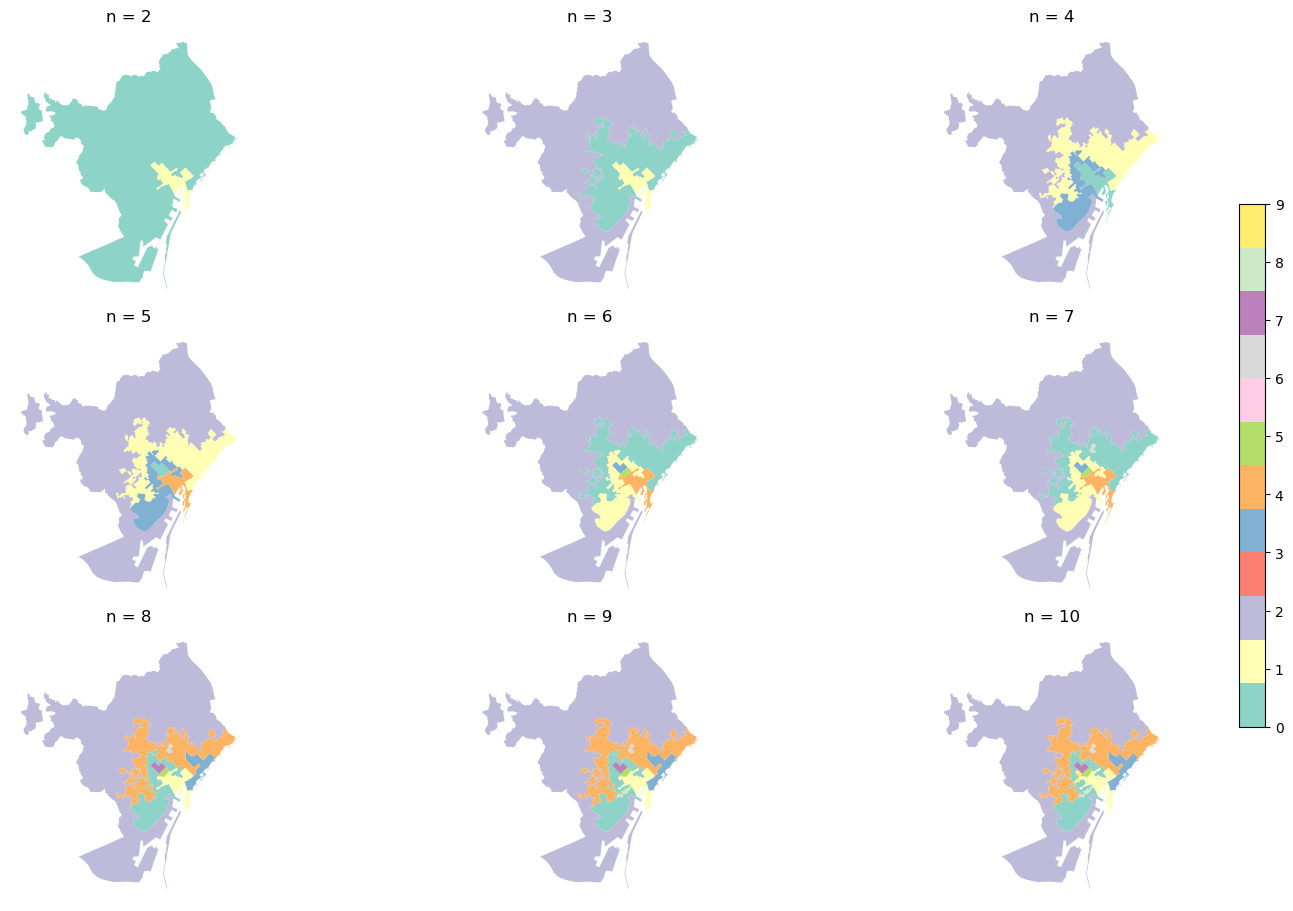

In [70]:
import math
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import cm

min_square_edge = math.ceil(math.sqrt(len(n_variants)))
min_label = 0
max_label = max(n_variants) - 1
norm = mcolors.Normalize(vmin=0, vmax=max_label)
cmap='Set3'
fig, axs = plt.subplots(min_square_edge, min_square_edge, figsize=(15, 9), layout="constrained")
axs = axs.flatten()
for n_variant, ax in zip(n_variants, axs):
    agg_column = cluster_column(n_variant)
    dissolved_gdf = airbnb_counts_per_census_area_clusters_gdf.dissolve([agg_column]).reset_index()
    dissolved_gdf.plot(agg_column, ax=ax, legend=False, cmap=cmap, norm=norm)
    ax.set_axis_off()
    ax.set_title(f"n = {n_variant}")
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=axs, shrink=0.6)
plt.show()

We can see from looking at changes across different values of `n`, that `n = 6` is the last one at which no major further changes in clusters occurred (based on visible area changing)

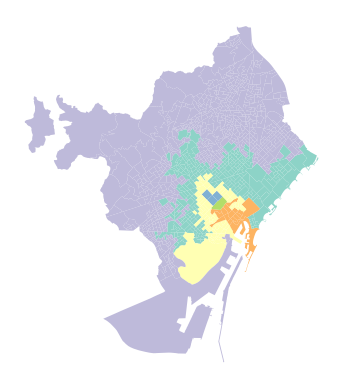

In [71]:
best_n = 6
agg_column = cluster_column(best_n)
dissolved_gdf = airbnb_counts_per_census_area_clusters_gdf.dissolve([agg_column]).reset_index()
ax = airbnb_counts_per_census_area_clusters_gdf.plot(agg_column, legend=False, cmap=cmap, norm=norm)
ax.set_axis_off()

### Summing up

> What does it say about the city?

It follows what we've seen in the hotspot visualisations i.e. that there is a cluster in the centre of barcelona. These additional agglomerative clusters show how the clusters spread out from this spot.